# Traffic map-matching quality report — Mapbox & TomTom

How well do the **provider traffic segments** map-match onto the **OSM driving edges**?
The DuckDB history tables only keep the winning ("most severe") congestion per edge, so
they can't answer questions about *coverage* or *cardinality*. This notebook re-runs the
exact pipeline matching (25 m corridor, ≤ 45° bearing, ≥ 40% overlap — from
`scripts.mapbox_traffic` / `scripts.tomtom_traffic`) but records **every** segment→edge
pair, so we can measure:

- total OSM edges, how many **matched** vs **unmatched**
- provider segments that matched **nothing** (orphans)
- **M:1** — one edge claimed by several segments — and **1:N** — one segment spread over many edges
- **conflicts** — M:1 edges where the segments disagreed on the level (info lost by "most severe wins")
- coverage by **highway class**, match **quality** (overlap / bearing), and a **cross-source** comparison

All logic lives in `scripts/matching_report.py`; this notebook is just the presentation layer.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scripts.matching_report import (
    build_report, compare_sources, print_text_report,
    annotate_edges, conflict_table,
)

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 120)

# ── Pick the area (must have db/<AREA>.duckdb and output/<AREA>_traffic_*.geojson) ──
AREA    = "sodermalm"          # try: sundbyberg · lidingo · nacka · tartu
SOURCES = ["mapbox", "tomtom"]
AREA

'sodermalm'

In [2]:
# Build the report for each source (re-runs the matching with full provenance)
reports = {s: build_report(AREA, s, db_dir=ROOT / "db", output_dir=ROOT / "output")
           for s in SOURCES}

for s in SOURCES:
    print_text_report(reports[s])


  Matching report — sodermalm / mapbox
  OSM edges (lines)        : 4,554  (191.6 km)
  Provider segments (used) : 3,554
  Matched edges            : 4,465  (98.0%)
  Unmatched edges          : 89
  Matched length           : 184.6 km  (96.4%)
  Orphan segments          : 1,189  (33.5%)
  Matched pairs (total)    : 12,451
  M:1 edges (≥2 segments)  : 2,984  (66.8% of matched, max 22)
     ↳ with level conflict : 49  (1.6% of M:1)
  1:N segments (≥2 edges)  : 2,045  (max 95)
  Overlap frac (median)    : 1.0
  Bearing diff (median)    : 0.44°

  Coverage by highway class:
       highway  edges  matched  matched_pct    km
         trunk     15       15        100.0  4.59
    trunk_link     14       14        100.0  1.14
       primary     21       20         95.2  1.59
  primary_link      8        8        100.0  0.11
     secondary    173      169         97.7 15.39
secondary_link     14       14        100.0  0.15
      tertiary    365      364         99.7 17.48
 tertiary_link      4 

## 1. Headline metrics — side by side

`n_edges` is the OSM line network; `n_matched` / `n_unmatched` answer the core question.
`km_matched_pct` is the length-weighted version (a fairer coverage number than edge counts,
since edges vary a lot in length).


In [3]:
metrics_df = pd.DataFrame({s: reports[s]["metrics"] for s in SOURCES})
metrics_df

,mapbox,tomtom
area,sodermalm,sodermalm
source,mapbox,tomtom
n_edges,4554,4554
n_segments,3554,72
n_matched,4465,1727
n_unmatched,89,2827
matched_pct,98.0,37.9
km_total,191.6,191.6
km_matched,184.6,66.4
km_matched_pct,96.4,34.7


## 2. Matched vs unmatched edges

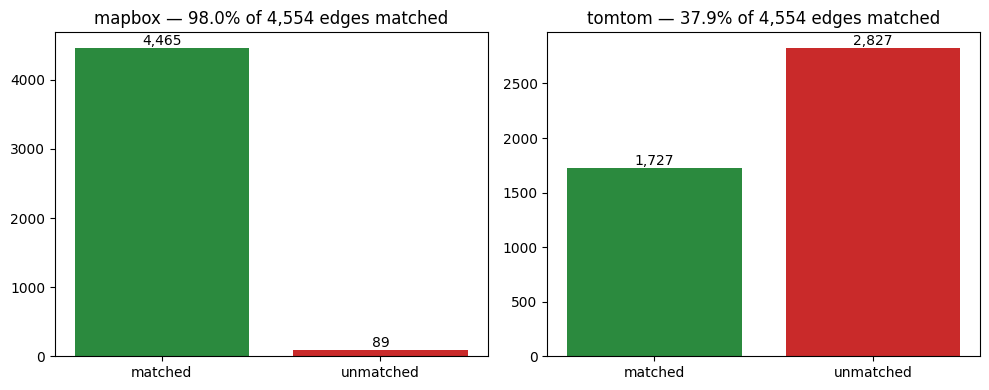

In [4]:
fig, axes = plt.subplots(1, len(SOURCES), figsize=(5 * len(SOURCES), 4))
if len(SOURCES) == 1:
    axes = [axes]
for ax, s in zip(axes, SOURCES):
    m = reports[s]["metrics"]
    ax.bar(["matched", "unmatched"], [m["n_matched"], m["n_unmatched"]],
           color=["#2b8a3e", "#c92a2a"])
    ax.set_title(f"{s} — {m['matched_pct']}% of {m['n_edges']:,} edges matched")
    for i, v in enumerate([m["n_matched"], m["n_unmatched"]]):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 3. Cardinality — is there M:1 (and 1:N)?

- **M:1** = one OSM edge matched by **≥ 2** segments. Common and mostly harmless here
  (parallel/duplicate provider geometry over the same road), unless the segments *disagree*
  (see §4).
- **1:N** = one provider segment spread over **≥ 2** OSM edges. Normal — provider segments
  are usually longer than OSM edges, so one long segment paints many short edges.

The histograms below count edges by *segments-per-edge* and segments by *edges-per-segment*.



=== mapbox — segments per edge ===
 segments_per_edge  edges
                 1   1481
                 2   1138
                 3    709
                 4    450
                 5    216
                 6    171
                 7     93
                 8     97
                 9     33
                10     27
                11      9
                12     20
                13      1
                14      7
                15      2
                16      7
                17      1
                18      2
                22      1
=== mapbox — edges per segment ===
 edges_per_segment  segments
                 1       320
                 2       627
                 3       218
                 4       373
                 5       117
                 6       185
                 7        82
                 8       102
                 9        42
                10        49
                11        31
                12        36
                13        24
   

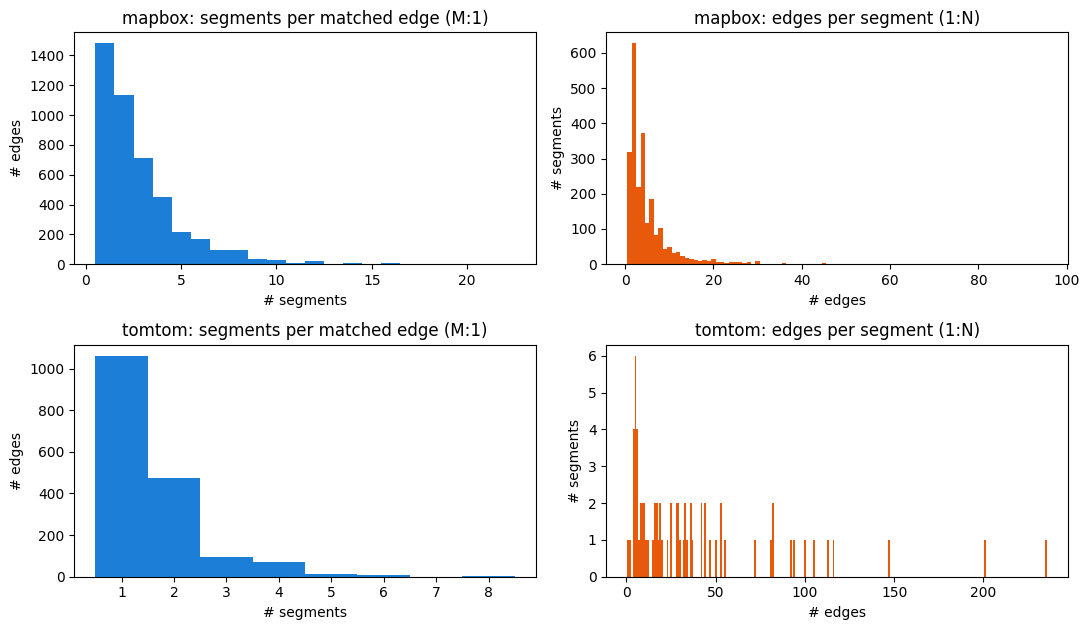

In [5]:
for s in SOURCES:
    print(f"\n=== {s} — segments per edge ===")
    print(reports[s]["segs_per_edge_hist"].to_string(index=False))
    print(f"=== {s} — edges per segment ===")
    print(reports[s]["edges_per_seg_hist"].to_string(index=False))

fig, axes = plt.subplots(len(SOURCES), 2, figsize=(11, 3.2 * len(SOURCES)))
axes = axes.reshape(len(SOURCES), 2)
for row, s in zip(axes, SOURCES):
    spe = reports[s]["segs_per_edge"]
    eps = reports[s]["edges_per_seg"]
    row[0].hist(spe.values, bins=range(1, int(spe.max()) + 2), color="#1c7ed6", align="left")
    row[0].set(title=f"{s}: segments per matched edge (M:1)", xlabel="# segments", ylabel="# edges")
    row[1].hist(eps.values, bins=range(1, int(eps.max()) + 2), color="#e8590c", align="left")
    row[1].set(title=f"{s}: edges per segment (1:N)", xlabel="# edges", ylabel="# segments")
plt.tight_layout(); plt.show()

## 4. Conflicts — where M:1 actually loses information

These are M:1 edges whose contributing segments reported **different** congestion levels.
The pipeline keeps the most severe and discards the rest; this table shows what was dropped.
A high conflict rate would mean the simple "most severe wins" rule is masking real
disagreement (e.g. opposite carriageways with different congestion bleeding into one edge).


In [6]:
for s in SOURCES:
    ct = conflict_table(reports[s], limit=15)
    m  = reports[s]["metrics"]
    print(f"\n=== {s}: {m['n_conflict_edges']} conflict edges "
          f"({m['conflict_pct_of_M_to_1']}% of M:1) — top {len(ct)} ===")
    if len(ct):
        print(ct[["edge_id", "name", "n_segments", "levels", "kept_most_severe"]].to_string(index=False))


=== mapbox: 49 conflict edges (1.6% of M:1) — top 15 ===
 edge_id           name  n_segments                 levels kept_most_severe
    2713       Götgatan          15        [low, moderate]         moderate
    2887 Långholmsgatan          11 [low, moderate, heavy]            heavy
    2115            NaN           9        [low, moderate]         moderate
     448   Östgötagatan           9           [low, heavy]            heavy
    1728 Verkstadsgatan           9           [low, heavy]            heavy
    1881     Hornsgatan           8        [low, moderate]         moderate
     299       Åsögatan           8        [low, moderate]         moderate
    4122            NaN           8        [low, moderate]         moderate
    2408            NaN           8        [low, moderate]         moderate
    2829      Ringvägen           7           [low, heavy]            heavy
    2156     Hornsgatan           6        [low, moderate]         moderate
    3927 Verkstadsgatan       

## 5. Coverage by highway class

Sorted by road importance (motorway → … → service). Tells you *which kinds* of road are
well covered. Expect arterials (trunk/primary/secondary) near 100% and small service roads
lower — especially for TomTom, which only emits segments where it has flow data.


In [7]:
for s in SOURCES:
    print(f"\n=== {s} — coverage by highway ===")
    print(reports[s]["highway_table"][["highway", "edges", "matched", "matched_pct", "km"]]
          .to_string(index=False))


=== mapbox — coverage by highway ===
       highway  edges  matched  matched_pct    km
         trunk     15       15        100.0  4.59
    trunk_link     14       14        100.0  1.14
       primary     21       20         95.2  1.59
  primary_link      8        8        100.0  0.11
     secondary    173      169         97.7 15.39
secondary_link     14       14        100.0  0.15
      tertiary    365      364         99.7 17.48
 tertiary_link      4        4        100.0  0.05
  unclassified    195      188         96.4 12.68
   residential   2819     2776         98.5 94.18
 living_street     17       17        100.0  0.80
       service    909      876         96.4 43.43

=== tomtom — coverage by highway ===
       highway  edges  matched  matched_pct    km
         trunk     15        8         53.3  4.59
    trunk_link     14        8         57.1  1.14
       primary     21       19         90.5  1.59
  primary_link      8        8        100.0  0.11
     secondary    173   

## 6. Match quality — overlap fraction & bearing difference

For every accepted pair: `overlap_frac` (how much of the edge sat inside the segment's
25 m corridor — higher is better) and `bear_diff` (degrees between segment and edge bearing).

> **Note:** `bear_diff` can come out **negative** because the pipeline's `_dir_diff`
> folds with `min(d, 180-d)` on a value that can exceed 180° (the 0/360 wrap quirk).
> Negative values are still treated as "aligned" by the filter — watch for a cluster of
> them, which means the bearing filter wrapped rather than measured a true small angle.


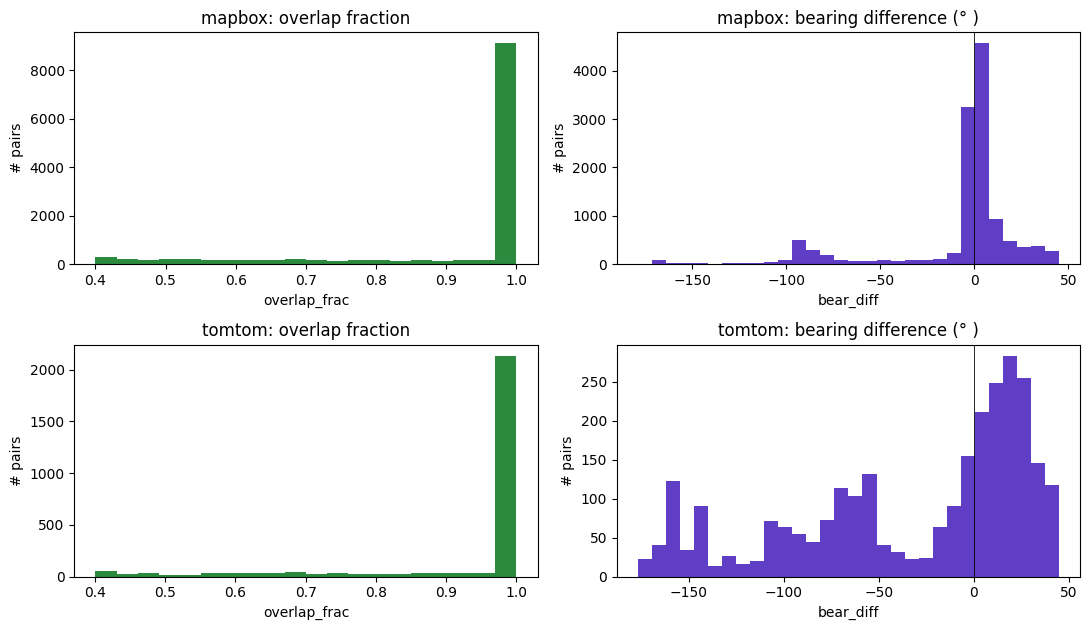

mapbox: overlap_frac & bear_diff summary
       overlap_frac  bear_diff
count     12451.000  12451.000
mean          0.910     -8.656
std           0.172     36.473
min           0.400   -178.930
25%           0.928     -0.670
50%           1.000      0.440
75%           1.000      4.250
max           1.000     44.990
tomtom: overlap_frac & bear_diff summary
       overlap_frac  bear_diff
count      2722.000   2722.000
mean          0.932    -32.373
std           0.151     62.544
min           0.401   -176.800
25%           1.000    -74.065
50%           1.000     -1.200
75%           1.000     19.482
max           1.000     44.930


In [8]:
fig, axes = plt.subplots(len(SOURCES), 2, figsize=(11, 3.2 * len(SOURCES)))
axes = axes.reshape(len(SOURCES), 2)
for row, s in zip(axes, SOURCES):
    mt = reports[s]["matches"]
    row[0].hist(mt["overlap_frac"], bins=20, color="#2b8a3e")
    row[0].set(title=f"{s}: overlap fraction", xlabel="overlap_frac", ylabel="# pairs")
    row[1].hist(mt["bear_diff"], bins=30, color="#5f3dc4")
    row[1].axvline(0, color="k", lw=0.6)
    row[1].set(title=f"{s}: bearing difference (° )", xlabel="bear_diff", ylabel="# pairs")
plt.tight_layout(); plt.show()

for s in SOURCES:
    print(f"{s}: overlap_frac & bear_diff summary")
    print(reports[s]["matches"][["overlap_frac", "bear_diff"]].describe().round(3).to_string())

## 7. Cross-source comparison

Which edges did both sources match, which only one — and where both matched, do they
agree on the congestion level?


In [9]:
if len(SOURCES) == 2:
    cmp = compare_sources(reports[SOURCES[0]], reports[SOURCES[1]])
    print(f"matched {cmp['source_a']}: {cmp['matched_a']:,}   "
          f"matched {cmp['source_b']}: {cmp['matched_b']:,}")
    print(f"both: {cmp['both']:,}   only {cmp['source_a']}: {cmp['only_a']:,}   "
          f"only {cmp['source_b']}: {cmp['only_b']:,}")
    print(f"agree on level (of 'both'): {cmp['agree_on_level']:,}  ({cmp['agree_pct']}%)")
    cmp

matched mapbox: 4,465   matched tomtom: 1,727
both: 1,717   only mapbox: 2,748   only tomtom: 10
agree on level (of 'both'): 1,601  (93.2%)


## 8. Map — unmatched & M:1 edges

Visual sanity check for one source: **red** = unmatched edges (coverage gaps),
**purple** = M:1 edges (≥ 2 segments — candidate over-matching / parallel-road bleed),
**grey** = ordinary 1-segment matches. Change `MAP_SOURCE` to inspect the other source.


In [12]:
import folium

MAP_SOURCE = "mapbox"          # or "tomtom"
MAP_SOURCE = "tomtom"          # or "mapbox"

ann = annotate_edges(reports[MAP_SOURCE]).to_crs("EPSG:4326")
ann = ann[ann.geometry.geom_type.isin(["LineString", "MultiLineString"])]

c = ann.geometry.union_all().centroid
m = folium.Map(location=[c.y, c.x], zoom_start=14, tiles="cartodbpositron")

def _style(feat):
    n = feat["properties"]["n_segments"]
    if n == 0:
        return {"color": "#c92a2a", "weight": 3}      # unmatched
    if n >= 2:
        return {"color": "#7048e8", "weight": 2}      # M:1
    return {"color": "#adb5bd", "weight": 1}          # 1 segment

folium.GeoJson(
    ann[["edge_id", "highway", "name", "n_segments", "matched", "geometry"]].__geo_interface__,
    style_function=_style,
    tooltip=folium.GeoJsonTooltip(fields=["edge_id", "highway", "name", "n_segments"]),
).add_to(m)
print(f"{MAP_SOURCE}: red=unmatched, purple=M:1 (≥2 segs), grey=1 segment")
m

tomtom: red=unmatched, purple=M:1 (≥2 segs), grey=1 segment


## 9. Route matcher — `NO_MATCH` segments (Filter 1 validation)

The default **route** matcher drops weak provider segments at **Filter 1** (`resolve_routes`)
→ `NO_MATCH`, using the per-provider thresholds in `config/match_thresholds.yaml`. Before
trusting those thresholds, eyeball the dropped segments here: **red** = `no_match` (should
genuinely lack a good OSM counterpart), **grey** = matched. Change `RM_SOURCE` to switch provider.


In [11]:
from scripts.route_match import segment_match_status, load_match_thresholds
import folium

RM_SOURCE = "tomtom"          # or "mapbox"
_th = load_match_thresholds(ROOT / "config" / "match_thresholds.yaml")
_status = segment_match_status(
    reports[RM_SOURCE]["edges"], reports[RM_SOURCE]["segments"],
    extra_cols=(("traffic_level",) if RM_SOURCE == "tomtom" else ()),
    segment_match=_th.get(RM_SOURCE, {}).get("segment_match"),
)
print(RM_SOURCE, "Filter-1 status:", _status["match_status"].value_counts().to_dict())

_ln = _status[_status.geometry.geom_type == "LineString"]
_c = _ln.geometry.union_all().centroid
_m = folium.Map(location=[_c.y, _c.x], zoom_start=14, tiles="cartodbpositron")
folium.GeoJson(
    _ln[["seg_id", "congestion", "match_status", "geometry"]].__geo_interface__,
    style_function=lambda f: {
        "color": "#c92a2a" if f["properties"]["match_status"] == "no_match" else "#adb5bd",
        "weight": 4 if f["properties"]["match_status"] == "no_match" else 1.5},
    tooltip=folium.GeoJsonTooltip(fields=["seg_id", "congestion", "match_status"]),
).add_to(_m)
print("red = no_match (validate these are truly unmatched), grey = matched")
_m


tomtom Filter-1 status: {'matched': 742, 'no_match': 251}
red = no_match (validate these are truly unmatched), grey = matched
